# Simulation Comparison
Here, I consider a single latitude and mixed layer depth, and compare directly two simulations.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic, get_heat_cap_lambda_eff
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [46]:
depth_use = 5 # 5 or 20
lat_use = 40
take_annual_harmonic = True         # whether to take annual harmonic of all variables from outset or not
exp_name = ['no_wind_dry', 'sw_dry', 'wind_moist', 'sw_wind_moist']
n_exp = len(exp_name)
ds_base = []
exp_sphum_set0 = []
varying_attrs = ['drag_coef', 'rh_flux_q', 'odp_sw', 'sw_abs', 'albedo']
for i in tqdm(range(n_exp)):
    ds_base.append(utils.load_ds(exp_name=f"thesis_season/column/depth={depth_use}/{exp_name[i]}", lat_min=30,
                                 var_keep=utils.var_keep + ['drag_q', 'olr', 'sphum'], low_lev_only=False,
                                 first_month_file=2).sel(lat=lat_use, method="nearest"))
    if 'sphum' not in ds_base[i]:
        ds_base[i]['sphum'] = ds_base[i]['temp']*0
        exp_sphum_set0.append(exp_name[i])
    # Add attributes as these can vary between experiments
    for var in varying_attrs:
        if var in ds_base[i].attrs:
            ds_base[i][var] = ds_base[i].attrs[var]
if len(exp_sphum_set0) > 0:
    print(f'Set sphum=0 for {exp_sphum_set0}')

exp_name = xr.DataArray(exp_name, dims="exp", name='exp')
ds_base = xr.concat(ds_base, dim=exp_name).squeeze()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Removing sphum from var_keep


  0%|          | 0/1 [00:00<?, ?it/s]

Removing sphum from var_keep


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Set sphum=0 for ['no_wind_dry', 'sw_dry']


In [47]:
def get_p_eff(p_surf, temp=280, lapse_rate=6.5 / 1000):
    # Characteristic pressure for the q^* distribution, accounts for more q^* near the surface
    p_alpha_calc = 1000 * 100  # clausius clapeyron parameter is insensitive to pressure
    beta = clausius_clapeyron_factor(temp, p_alpha_calc) * lapse_rate * R * temp / g
    return (beta + 1) / (beta + 2) * p_surf


def get_temp_from_sphum_sat(sphum_sat_target, p, guess_temp: float = 280):
    fit_func = lambda x: sphum_sat(x, p) - sphum_sat_target
    return scipy.optimize.fsolve(fit_func, np.full_like(sphum_sat_target, guess_temp))


get_temp_from_sphum_sat_xr = wrap_with_apply_ufunc(get_temp_from_sphum_sat, input_core_dims=[[], []],
                                                   output_core_dims=[[]])

In [48]:
ds_base['p_lev'] = ds_base.sigma_atm * ds_base.p_surf.max()
ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['sphum_col'] = mass_weighted_vertical_integral(ds_base.sphum, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['rh_col'] = ds_base['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base.temp, ds_base.p_lev),
                                                                           ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['p_eff'] = get_p_eff(ds_base.p_surf.max(dim=['time']))
ds_base['temp_col_sphum'] = get_temp_from_sphum_sat_xr(ds_base.sphum_col / ds_base.rh_col, ds_base.p_eff)

for i in range(n_exp):
    if 'dry' in exp_name[i]:
        # If no wind, there is very little column humidity, so this gives the best approx
        ds_base.isel(exp=i)['rh_col'] *= 0

ds = utils.get_annual_zonal_mean(ds_base.expand_dims('lon'))
if take_annual_harmonic:
    # Take annual harmonic of all variables for simplicity
    for key in ds:
        if 'time' in ds[key].dims:
            try:
                ds[key] = get_fourier_fit_xr(ds.time, ds[key], n_harmonics=1, pad_coefs_phase=True)[0]
            except ValueError:
                print(key)

/Users/joshduffield/miniforge3/envs/Isca/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


q_surf


In [49]:
coef_temp = {'amp': {}, 'phase': {}}
for key in ['col', 'col_sphum', 'rad_atm', 'rad_surf']:
    coef_temp['amp'][key], coef_temp['phase'][key] = utils.get_fit_coef_complex(ds[f"temp_{key}"], ds.temp_atm, ds.time)

### Approximating Flux with $\lambda$ feedback parameters
Below I do a sanity check that the computed $\lambda$ feedback parameters correctly approximate the tendency of both the surface temperature, and the atmospheric column energy.

In [50]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp = np.abs(coef_amp.sel(harmonic=1))
coef_phase = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
heat_cap_multiplier = get_heat_capacity(c_p_ocean, rho_ocean,
                                        coef_sw_amp * np.sin(coef_phase) / (2 * np.pi * f) / coef_amp,
                                        True) / ds.depth
heat_capacity_eff = ds.heat_capacity * heat_cap_multiplier
lambda_s1_eff = coef_sw_amp * np.cos(coef_phase) / coef_amp

In [51]:
# Different method, sanity check that gives same results
# Defined the lambda parameters differently as to be more in keeping with literature.
# Now have some feedback parameters which are expected to be small
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_feedback_params_analytic).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['sigma_atm'] = args_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
args_use['drag_coef'] = ds_use.drag_coef
args_use['pressure_heat_cap_atmos_calc'] = float(ds['p_lev'].max() - ds['p_lev'].min())
args_use['p_col_sphum'] = ds_use.p_eff
args_use['coef_amp_rad_surf'] = coef_temp['amp']['rad_surf']
args_use['coef_amp_olr'] = coef_temp['amp']['rad_atm']
args_use['coef_amp_col_sphum'] = coef_temp['amp']['col_sphum']

var = get_feedback_params_analytic(**args_use)
feedback_params = {'mu': None, 'lambda_const': None, 'B': None, 'lambda_sh': None, 'lambda_lh': None, 'lambda_lw1': None, 'lambda_lw2': None}
for i, key in enumerate(feedback_params):
    feedback_params[key] = var[i]
feedback_params['coef_amp_col'] = coef_temp['amp']['col']
feedback_params['coef_phase_col'] = coef_temp['phase']['col']
feedback_params['coef_phase_olr'] = coef_temp['phase']['rad_atm']
lambda_s1_multiplier_theory, heat_cap_multiplier_theory = get_heat_cap_lambda_eff(**feedback_params, heat_cap_surf=ds.heat_capacity,
                         pressure_heat_cap_atmos_calc=args_use['pressure_heat_cap_atmos_calc'], albedo=ds.albedo, sw_abs=ds.sw_abs)
lambda_s1_eff_theory = feedback_params['lambda_const'] * lambda_s1_multiplier_theory
heat_capacity_eff_theory = ds.heat_capacity * heat_cap_multiplier_theory
coef_phase_theory = np.arctan(omega * heat_capacity_eff_theory / lambda_s1_eff_theory)
coef_amp_theory = coef_sw_amp / np.sqrt(omega ** 2 * heat_capacity_eff_theory ** 2 + lambda_s1_eff_theory ** 2)

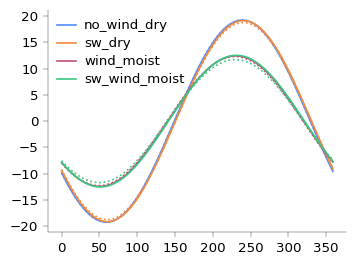

In [52]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col']*0.7)
for i in range(ds.exp.size):
    ds_use = ds.isel(exp=i)
    ax.plot(ds.time, ds_use.temp_surf-ds_use.temp_surf.mean(dim='time'), color=f"C{i}", label=f"{ds.exp[i].values}")
    amp_theory_use = coef_amp_theory.isel(exp=i)
    phase_theory_use = coef_phase_theory.isel(exp=i)
    ax.plot(ds.time, fourier_series(ds.time, [0, -amp_theory_use],
                                    [0, phase_theory_use], pad_coefs_phase=True), color=f"C{i}", linestyle=':')
update_linewidth(fig)
ax.legend()
update_fontsize(fig)
plt.show()

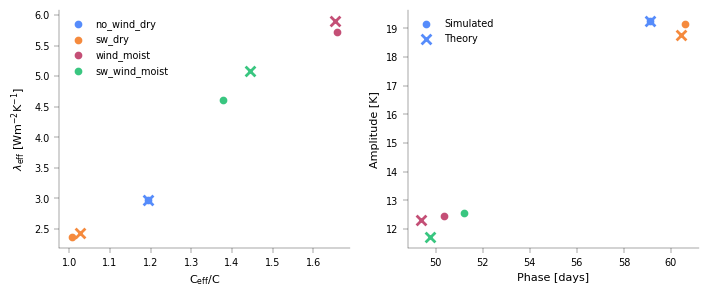

In [53]:
show_phase_time = True
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.exp.size):
    ax[0].scatter(heat_cap_multiplier.isel(exp=i), lambda_s1_eff.isel(exp=i), color=f'C{i}', label=f'{ds.exp[i].values}',
                  marker='.', s=50, lw=2)
    ax[0].scatter(heat_cap_multiplier_theory.isel(exp=i), lambda_s1_eff_theory.isel(exp=i),
                  color=f'C{i}', marker='x', s=50, lw=2)
    ax[1].scatter(coef_phase.isel(exp=i)/omega/utils.day_seconds if show_phase_time else
                  (omega * heat_capacity_eff / lambda_s1_eff).isel(exp=i), coef_amp.isel(exp=i),
                  color=f'C{i}', marker='.', s=50, lw=2, label='Simulated' if i==0 else None)
    ax[1].scatter(coef_phase_theory.isel(exp=i)/omega/utils.day_seconds if show_phase_time else
                  (omega * heat_capacity_eff_theory / lambda_s1_eff_theory).isel(exp=i), coef_amp_theory.isel(exp=i),
                  color=f'C{i}', marker='x', s=50, lw=2, label='Theory' if i==0 else None)
    # ax[0].plot(ds.lat, heat_cap_multiplier_theory.isel(exp=i), color=f'C{i}', linestyle=':')
    # ax[1].plot(ds.lat, lambda_s1_eff.isel(exp=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    # ax[1].plot(ds.lat, lambda_s1_eff_theory.isel(exp=i), color=f'C{i}', linestyle=':',
    #            label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
update_linewidth(fig)
ax[0].set_xlabel("C$_{\\text{eff}}/$C")
ax[0].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
ax[1].set_xlabel("Phase [days]" if show_phase_time else "$\\tan (\\phi)$")
ax[1].set_ylabel("Amplitude [K]")
plt.show()